# Defect Detection Dataset - Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

sns.set_style('whitegrid')
%matplotlib inline

## 1. Dataset Overview

In [5]:
data_dir = Path('Data')
classes = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])

# Count images per class
class_counts = {}
for cls in classes:
    class_counts[cls] = len(list((data_dir / cls).glob('*.PNG')))

df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
print(f"Total classes: {len(classes)}")
print(f"Total images: {df['Count'].sum()}")
print(f"\nClass distribution:\n{df}")

Total classes: 9
Total images: 9796

Class distribution:
      Class  Count
0   defect1    253
1  defect10    674
2   defect2    178
3   defect3      9
4   defect4     14
5   defect5    411
6   defect8    803
7   defect9    319
8      good   7135


## 2. Class Distribution

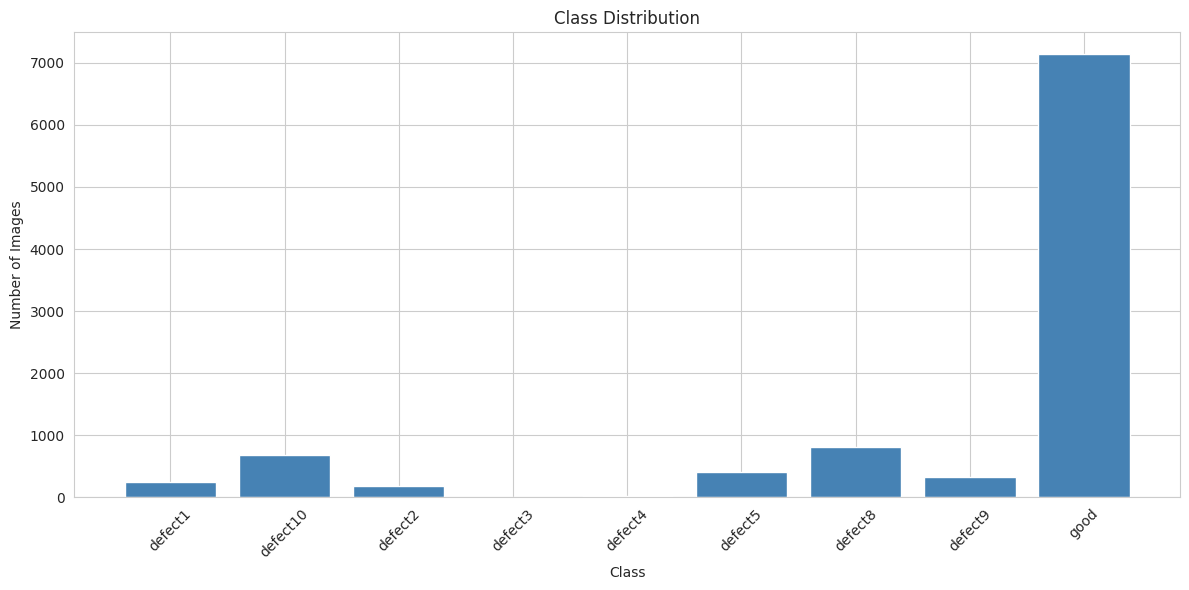

Class imbalance ratio: 792.78


In [6]:
plt.figure(figsize=(12, 6))
plt.bar(df['Class'], df['Count'], color='steelblue')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {df['Count'].max() / df['Count'].min():.2f}")

## 3. Image Dimensions Analysis

In [7]:
# Sample images from each class
image_dims = []
for cls in classes:
    for img_path in list((data_dir / cls).glob('*.PNG'))[:50]:  # Sample 50 per class
        img = Image.open(img_path)
        image_dims.append({'class': cls, 'width': img.width, 'height': img.height})

dims_df = pd.DataFrame(image_dims)
print(dims_df.groupby('class')[['width', 'height']].describe())

         width                                                          \
         count         mean          std    min    25%     50%     75%   
class                                                                    
defect1   50.0  1602.240000  1075.897472  648.0  973.5  1158.0  1580.0   
defect10  50.0   692.880000   139.827976  602.0  646.0   656.0   672.0   
defect2   50.0   666.440000    40.872704  620.0  638.0   640.0   696.5   
defect3    9.0   770.222222   332.384483  614.0  620.0   638.0   670.0   
defect4   14.0  1189.142857   662.822271  830.0  898.0  1029.0  1100.5   
defect5   50.0   839.840000   333.837756  612.0  630.0   688.0   945.5   
defect8   50.0   771.680000   282.079555  606.0  634.0   672.0   773.5   
defect9   50.0   754.200000   151.656029  616.0  670.5   717.0   765.5   
good      50.0   926.680000   670.461018  612.0  645.5   692.0   835.5   

                 height                                                  \
             max  count         mean

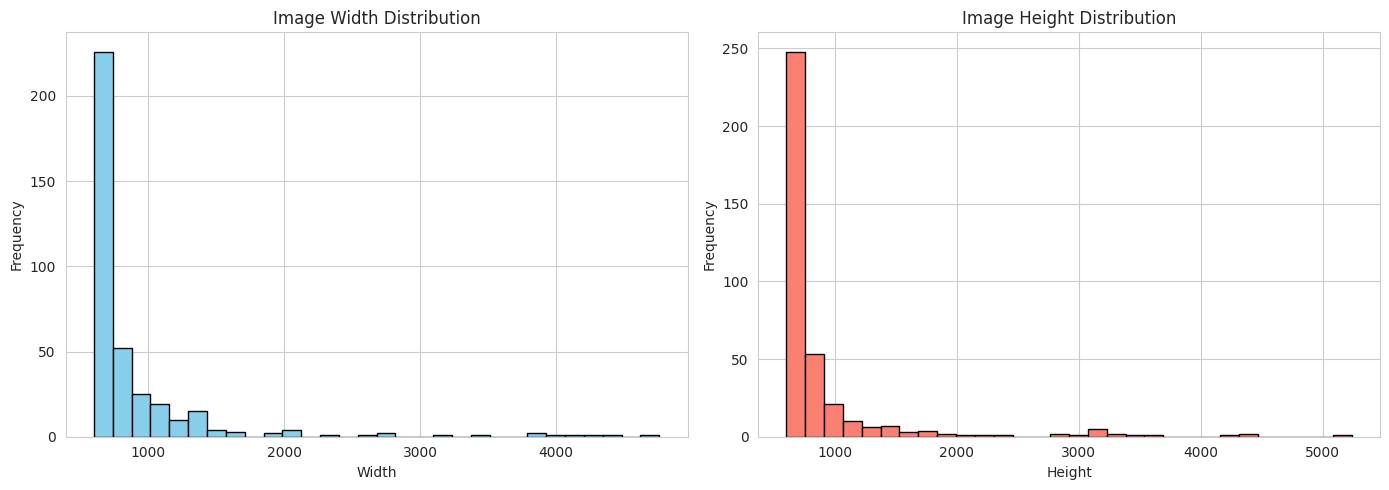

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dims_df['width'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Image Width Distribution')

axes[1].hist(dims_df['height'], bins=30, color='salmon', edgecolor='black')
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Image Height Distribution')

plt.tight_layout()
plt.show()

## 4. Sample Images Visualization

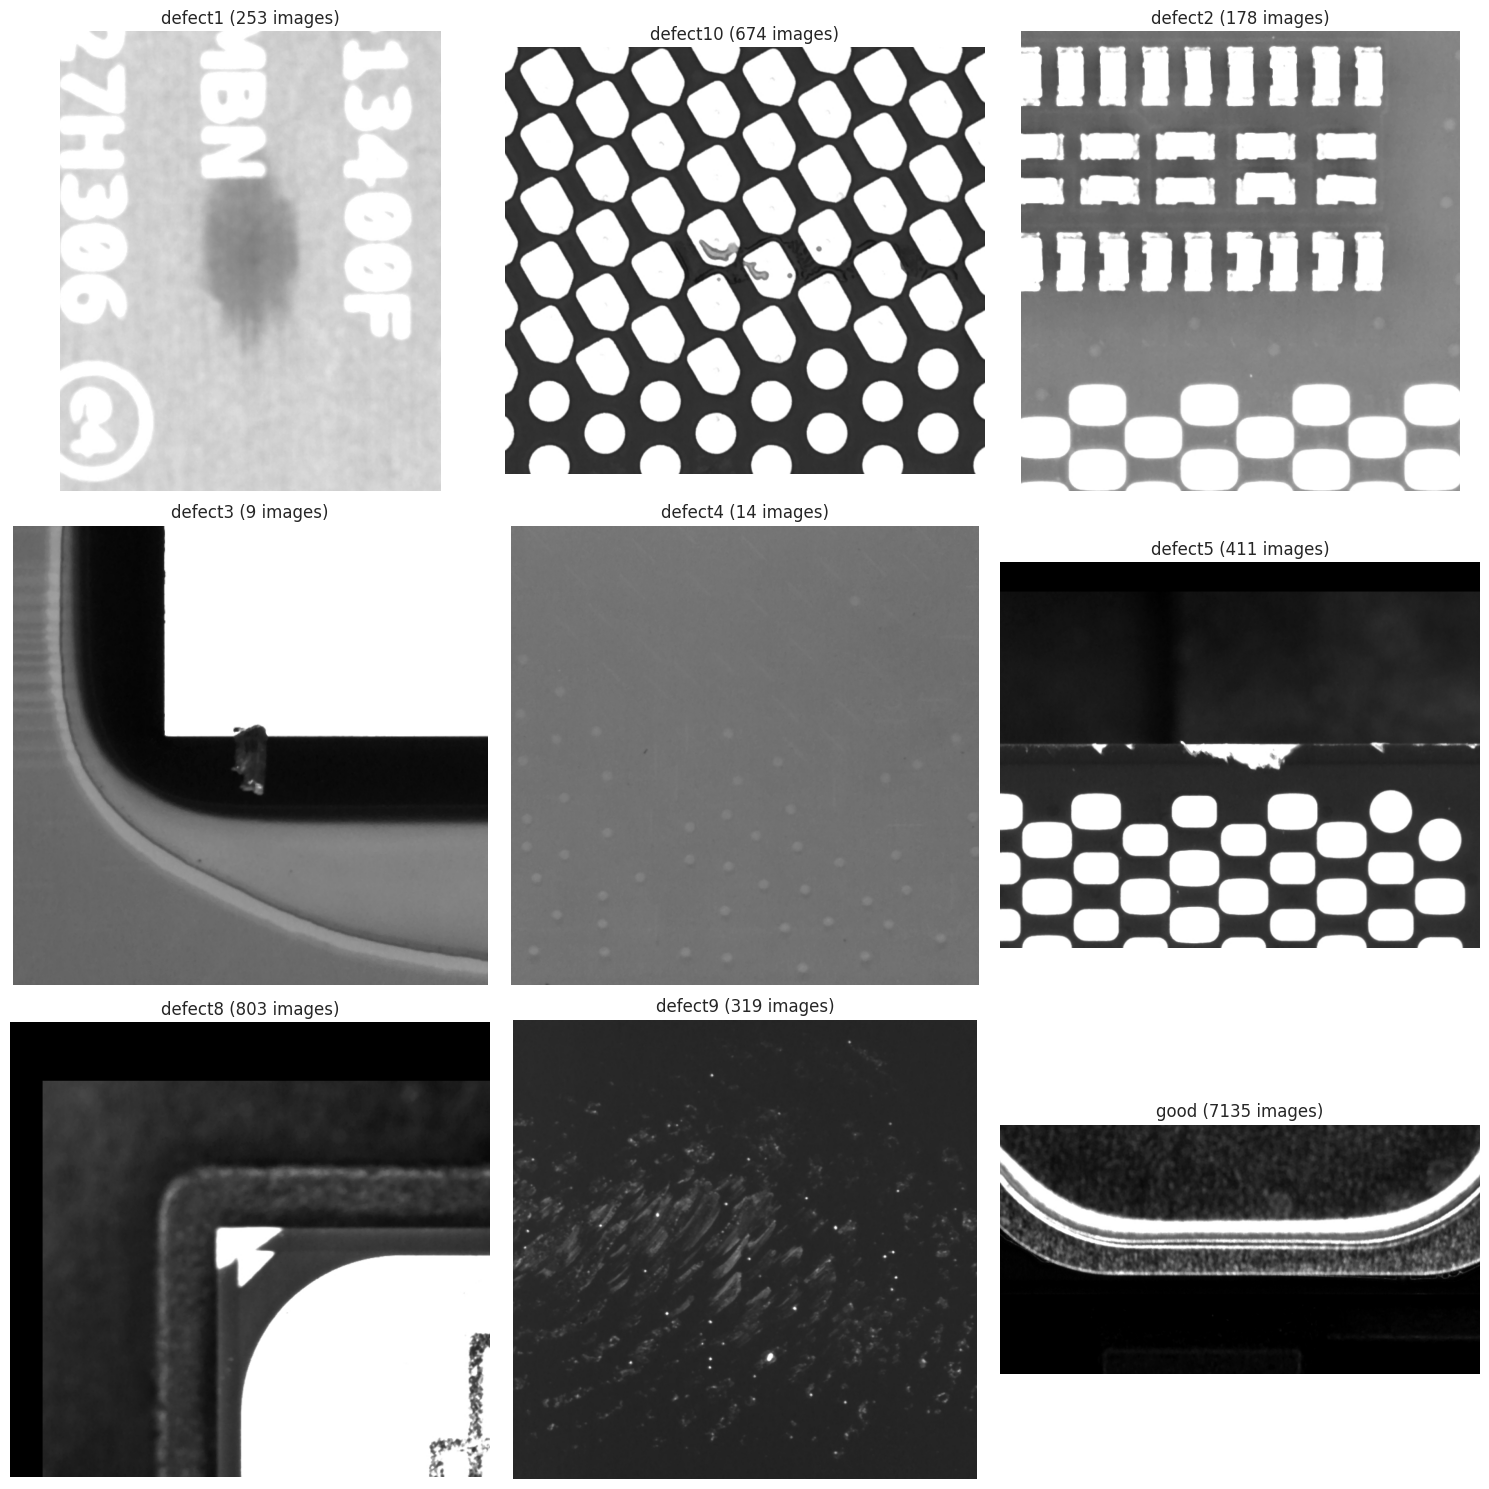

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    img_path = list((data_dir / cls).glob('*.PNG'))[0]
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'{cls} ({class_counts[cls]} images)')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 5. Pixel Intensity Analysis

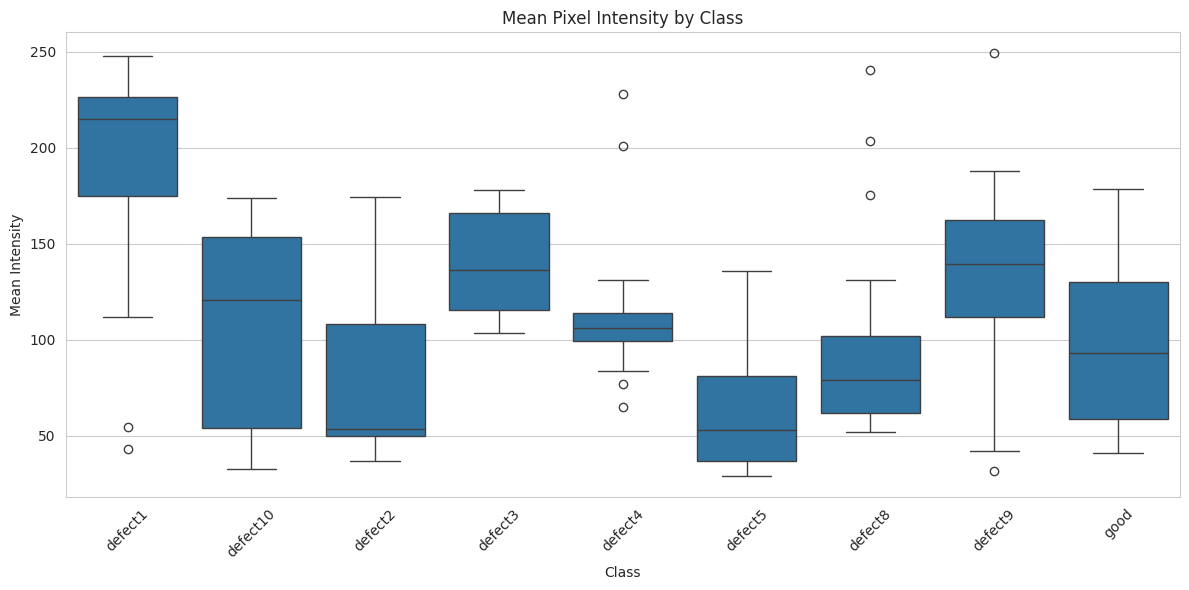

In [10]:
# Sample images for intensity analysis
mean_intensities = {cls: [] for cls in classes}

for cls in classes:
    for img_path in list((data_dir / cls).glob('*.PNG'))[:20]:
        img = np.array(Image.open(img_path).convert('L'))
        mean_intensities[cls].append(img.mean())

intensity_df = pd.DataFrame([(k, v) for k, vals in mean_intensities.items() for v in vals], 
                            columns=['Class', 'Mean Intensity'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=intensity_df, x='Class', y='Mean Intensity')
plt.xticks(rotation=45)
plt.title('Mean Pixel Intensity by Class')
plt.tight_layout()
plt.show()

## 6. Key Insights

In [11]:
print("=" * 50)
print("KEY INSIGHTS")
print("=" * 50)
print(f"1. Dataset is highly imbalanced - 'good' class has {class_counts['good']} samples")
print(f"2. Smallest defect classes: {df.nsmallest(3, 'Count')[['Class', 'Count']].to_dict('records')}")
print(f"3. Total defect samples: {df[df['Class'] != 'good']['Count'].sum()}")
print(f"4. Good vs Defect ratio: {class_counts['good'] / df[df['Class'] != 'good']['Count'].sum():.2f}")
print("\nRecommendations:")
print("- Use class weights or oversampling for minority classes")
print("- Consider focal loss for imbalanced classification")
print("- Apply data augmentation especially for defect classes")

KEY INSIGHTS
1. Dataset is highly imbalanced - 'good' class has 7135 samples
2. Smallest defect classes: [{'Class': 'defect3', 'Count': 9}, {'Class': 'defect4', 'Count': 14}, {'Class': 'defect2', 'Count': 178}]
3. Total defect samples: 2661
4. Good vs Defect ratio: 2.68

Recommendations:
- Use class weights or oversampling for minority classes
- Consider focal loss for imbalanced classification
- Apply data augmentation especially for defect classes
